# Oncología traslacional (TCGA) — Pasos 1 a 3 — TCGA-LUAD

Pipeline de extracción y curaduría ómica sobre el Genomic Data Commons:
indexación de cohortes, descarga automatizada de RNA-Seq (STAR - Counts) y
reducción de ~60.000 genes a 10 mediante regularización L1 / L2.

Mismo pipeline que el cuaderno de TCGA-KIRP, aplicado al adenocarcinoma de
pulmón.

In [6]:
import sys
import tarfile
from pathlib import Path

import numpy as np
import pandas as pd
import requests

sys.path.insert(0, str(Path.cwd().parent))  # notebooks/ -> raíz del repo

GDC = "https://api.gdc.cancer.gov"
PROYECTO = "TCGA-LUAD"

DATA_DIR = Path("../data/datos_tcga")
TAR_PATH = DATA_DIR / "tcga_luad_rna_seq.tar.gz"
PARCIAL = TAR_PATH.with_suffix(".parte")  # nombre mientras no esté verificado
TSV_DIR = DATA_DIR / "archivos_tsv_luad"
DATA_DIR.mkdir(parents=True, exist_ok=True)

---
## Paso 1 — Exploración e ingeniería de requisitos

Indexamos las cohortes del consorcio TCGA consultando el endpoint `/projects`
en vez de navegar el portal a mano.

In [7]:
respuesta = requests.get(
    f"{GDC}/projects",
    params={
        "filters": '{"op":"in","content":{"field":"program.name","value":["TCGA"]}}',
        "fields": "project_id,name,primary_site,summary.case_count",
        "size": "100",
        "format": "JSON",
    },
)

cohortes = pd.json_normalize(respuesta.json()["data"]["hits"])
cohortes = (
    cohortes.assign(primary_site=cohortes["primary_site"].str.join(", "))
    .rename(columns={"summary.case_count": "cases"})[
        ["project_id", "name", "primary_site", "cases"]
    ]
    .sort_values("cases", ascending=False)
    .reset_index(drop=True)
)

print(f"Cohortes TCGA indexadas: {len(cohortes)}")
cohortes.head(10)

Cohortes TCGA indexadas: 33


,project_id,name,primary_site,cases
0,TCGA-BRCA,Breast Invasive Carcinoma,Breast,1098
1,TCGA-GBM,Glioblastoma Multiforme,Brain,617
2,TCGA-OV,Ovarian Serous Cystadenocarcinoma,"Ovary, Retroperitoneum and peritoneum",608
3,TCGA-LUAD,Lung Adenocarcinoma,Bronchus and lung,585
4,TCGA-UCEC,Uterine Corpus Endometrial Carcinoma,"Corpus uteri, Uterus, NOS",560
5,TCGA-KIRC,Kidney Renal Clear Cell Carcinoma,Kidney,537
6,TCGA-HNSC,Head and Neck Squamous Cell Carcinoma,"Base of tongue, Lip, Gum, Hypopharynx, Palate,...",528
7,TCGA-LGG,Brain Lower Grade Glioma,Brain,516
8,TCGA-THCA,Thyroid Carcinoma,Thyroid gland,507
9,TCGA-LUSC,Lung Squamous Cell Carcinoma,Bronchus and lung,504


In [8]:
# Ficha técnica de la cohorte elegida (Diapositiva 3)
cohortes[cohortes["project_id"] == PROYECTO]

,project_id,name,primary_site,cases
3,TCGA-LUAD,Lung Adenocarcinoma,Bronchus and lung,585


**Por qué TCGA-LUAD.** El adenocarcinoma es el subtipo histológico más frecuente
del cáncer de pulmón, y el cáncer de pulmón es la primera causa de muerte por
cáncer en el mundo. Es además el tumor donde mejor cuajó la terapia dirigida:
sus alteraciones conductoras —*EGFR*, *KRAS*, y las fusiones de *ALK* y *ROS1*—
definen subgrupos con tratamiento propio, así que la expresión génica tiene un
correlato clínico directo. La cohorte incluye tejido tumoral y tejido normal
adyacente, lo que permite plantear un contraste supervisado tumor vs. normal.

---
## Paso 2 — Conexión y descarga automatizada

Una sola consulta al endpoint `/files` construye el manifiesto: identificadores
para descargar y metadatos (paciente, tipo de muestra) para etiquetar la matriz.

In [9]:
payload = {
    "filters": {
        "op": "and",
        "content": [
            {"op": "in", "content": {"field": "cases.project.project_id", "value": [PROYECTO]}},
            {"op": "in", "content": {"field": "files.data_type", "value": ["Gene Expression Quantification"]}},
            {"op": "in", "content": {"field": "files.analysis.workflow_type", "value": ["STAR - Counts"]}},
        ],
    },
    "fields": "file_id,file_name,cases.submitter_id,cases.samples.sample_type",
    "format": "JSON",
    "size": "1000",
}

hits = requests.post(f"{GDC}/files", json=payload).json()["data"]["hits"]

manifiesto = pd.DataFrame(
    [
        {
            "file_id": h["file_id"],
            "paciente": h["cases"][0]["submitter_id"],
            "tipo_muestra": h["cases"][0]["samples"][0]["sample_type"],
        }
        for h in hits
    ]
)
# Etiqueta única por muestra: un paciente puede aportar tumor y normal, y en
# esta cohorte algunos aportan además alícuotas repetidas del mismo tumor. Sin
# el sufijo, esas columnas se sobreescribirían al consolidar y se perderían
# muestras sin que nada avise.
manifiesto["muestra"] = (
    manifiesto["paciente"] + "-" + manifiesto["tipo_muestra"].str[:1]
)
repetida = manifiesto.groupby("muestra").cumcount()
manifiesto["muestra"] += np.where(repetida > 0, "-" + (repetida + 1).astype(str), "")

print(f"Archivos encontrados: {len(manifiesto)}")
manifiesto["tipo_muestra"].value_counts()

Archivos encontrados: 601


tipo_muestra
Primary Tumor          540
Solid Tissue Normal     59
Recurrent Tumor          2
Name: count, dtype: int64

**Por qué Python + Jupyter.** La API del GDC es REST/JSON, así que `requests` y
`pandas` bastan: no hace falta la pila Bioconductor de R. El entorno es un
`.venv` local del repositorio, lo que fija versiones y mantiene reproducible la
ejecución, y el mismo cuaderno encadena descarga, consolidación y modelado sin
exportar archivos intermedios.

In [15]:
# Descarga única: el GDC empaqueta todos los archivos en un solo .tar.gz.
# El paquete se guarda con nombre provisional (.parte) porque todavía no está
# verificado: la respuesta llega con Transfer-Encoding chunked y sin
# Content-Length, así que una conexión cortada termina el stream sin lanzar
# error y no hay tamaño esperado contra el cual compararlo.
# Un 500 aquí suele ser una petición simultánea o repetida del mismo paquete:
# basta con reejecutar la celda.
if TAR_PATH.exists():
    print(f"Ya descargado y verificado: {TAR_PATH.name} ({TAR_PATH.stat().st_size / 1e6:.0f} MB)")
else:
    with requests.post(
        f"{GDC}/data",
        json={"ids": manifiesto["file_id"].tolist()},
        stream=True,
        timeout=(10, 180),
    ) as r:
        r.raise_for_status()
        with open(PARCIAL, "wb") as f:
            for bloque in r.iter_content(chunk_size=1024 * 1024):
                f.write(bloque)
    print(f"Descargado: {PARCIAL.name} ({PARCIAL.stat().st_size / 1e6:.0f} MB) — falta verificar")

Descargado: tcga_luad_rna_seq.tar.parte (625 MB) — falta verificar


In [16]:
# Descomprimir es la verificación de la descarga: si el paquete llegó truncado,
# tarfile falla aquí, el archivo conserva el nombre .parte y la próxima
# ejecución lo vuelve a bajar en vez de dar por buena una descarga rota. Solo
# tras una extracción completa pasa a llamarse .tar.gz, y desde ese momento no
# se repite ni la descarga ni la descompresión.
tsvs = sorted(TSV_DIR.glob("*/*.tsv"))

if len(tsvs) != len(manifiesto):
    paquete = TAR_PATH if TAR_PATH.exists() else PARCIAL
    with tarfile.open(paquete, "r:gz") as tar:
        tar.extractall(TSV_DIR, filter="data")
    paquete.replace(TAR_PATH)
    tsvs = sorted(TSV_DIR.glob("*/*.tsv"))

print(f"Archivos TSV extraídos: {len(tsvs)} de {len(manifiesto)}")

Archivos TSV extraídos: 601 de 601


In [17]:
# Consolidación: un TSV por muestra -> una sola matriz genes x pacientes.
COLUMNAS = ["gene_id", "gene_name", "gene_type", "tpm_unstranded"]
paciente_por_file_id = dict(zip(manifiesto["file_id"], manifiesto["muestra"]))

columnas, anotacion = {}, None
for ruta in tsvs:
    tabla = pd.read_csv(ruta, sep="\t", skiprows=1, usecols=COLUMNAS)
    # Las 4 primeras filas son los contadores de STAR (N_unmapped, ...), no genes.
    tabla = tabla[~tabla["gene_id"].str.startswith("N_")].set_index("gene_id")
    if anotacion is None:
        anotacion = tabla[["gene_name", "gene_type"]]
    columnas[paciente_por_file_id[ruta.parent.name]] = tabla["tpm_unstranded"]

expresion = pd.DataFrame(columnas)
print(f"Matriz de expresión: {expresion.shape[0]} genes x {expresion.shape[1]} pacientes")
expresion.iloc[:5, :4]

Matriz de expresión: 60660 genes x 601 pacientes


,TCGA-35-5375-P,TCGA-55-A4DF-P,TCGA-95-8039-P,TCGA-MP-A4T4-P
gene_id,,,,
ENSG00000000003.15,94.7370,66.7753,56.9884,28.3773
ENSG00000000005.6,0.0000,0.0000,0.1262,0.0000
ENSG00000000419.13,236.5221,201.2410,85.4816,78.1728
ENSG00000000457.14,4.1846,8.1025,7.4612,6.4525
ENSG00000000460.17,7.6534,7.7590,3.3145,3.6848


Se consolida `tpm_unstranded` (TPM) y no el conteo crudo: viene en la misma fila
del archivo STAR pero ya está normalizado por longitud del gen y profundidad de
secuenciación, así que las muestras son comparables entre sí sin añadir un paso
de normalización.

---
## Paso 3 — Regularización y curaduría de 10 genes

Con 60.660 genes y 601 muestras estamos en $P \gg N$: un ajuste sin penalización
tiene infinitas soluciones y memoriza el ruido. Como `y` es binaria se ajusta una
**regresión logística** del indicador tumor/normal sobre la expresión, y se
comparan las dos penalizaciones.

La lectura de cada gen es su **AOR** (*adjusted odds ratio*), $\text{AOR} = e^{\beta}$:
como `X` está estandarizada, es el factor por el que se multiplican las odds de
que la muestra sea tumor por **cada desviación estándar de aumento en
log2(TPM+1)**, ajustada por los demás genes del modelo. AOR > 1 acompaña al
tumor; AOR < 1 acompaña al tejido normal; AOR = 1 es indiferente.

### Variable objetivo

`y` es un **indicador binario tumor (1) / tejido normal (0)**, una entrada por
muestra y alineada con las filas de `X`.

**De dónde sale.** No se deriva de la matriz de expresión: viene de los
metadatos que el GDC devolvió en el Paso 2. En la consulta a `/files` se pidió
el campo `cases.samples.sample_type` dentro de `fields`, y ese valor quedó
guardado en la columna `manifiesto["tipo_muestra"]`.

**Cómo se construye**, en las tres operaciones de la celda siguiente:

1. `manifiesto.set_index("muestra")` — `muestra` es la etiqueta única que se
   armó en el Paso 2 como `paciente + "-" + inicial del tipo de muestra`, más un
   sufijo numérico cuando el mismo paciente aportó alícuotas repetidas; es la
   misma etiqueta que nombra las columnas de `expresion`, y por tanto las filas
   de `X = log_expr.T`.
2. `.loc[X.index]` reordena el manifiesto contra el índice de `X`, de modo que
   cada muestra recibe su propia etiqueta (alineación por nombre, no por
   posición).
3. `!= "Solid Tissue Normal"` hace la codificación 1/0:

| `tipo_muestra` | n | `y` |
| --- | --- | --- |
| `Primary Tumor` | 540 | 1 |
| `Recurrent Tumor` | 2 | 1 |
| `Solid Tissue Normal` | 59 | 0 |

Es decir **542 tumor / 59 normal**. Como la etiqueta es metadato del portal y no
una columna calculada a partir de la expresión, no hay fuga de información: las
AOR de la logística miden qué genes separan ambos grupos.

**Una salvedad propia de esta cohorte.** Los 601 archivos provienen de 518
pacientes: 83 son alícuotas repetidas del mismo tumor. El sufijo numérico evita
que se sobreescriban al consolidar, pero significa que un mismo paciente puede
caer en varios pliegues de la validación cruzada, lo que vuelve algo optimista
la estimación de desempeño.

In [18]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler

log_expr = np.log2(expresion + 1)

# Solo genes realmente expresados (TPM >= 1 en al menos el 20 % de las muestras).
expresados = (expresion >= 1).sum(axis=1) >= 0.2 * expresion.shape[1]

X = log_expr[expresados].T  # pacientes x genes
y = (
    manifiesto.set_index("muestra").loc[X.index, "tipo_muestra"]
    != "Solid Tissue Normal"
).astype(int)
X = pd.DataFrame(StandardScaler().fit_transform(X), index=X.index, columns=X.columns)

print(f"X: {X.shape[0]} muestras x {X.shape[1]} genes")
print(f"y: {y.sum()} tumor / {len(y) - y.sum()} normal")

X: 601 muestras x 21213 genes
y: 542 tumor / 59 normal


### Intento 1 — logística con penalización L1 (Lasso)

In [19]:
# Regresión logística porque y es binaria. l1_ratios=(1,) es la penalización L1
# en la API actual de scikit-learn (penalty= quedó deprecado en la 1.8).
# scoring="neg_log_loss": con clases casi separables la exactitud empata en
# muchos valores de C y no sirve para elegirlo.
# random_state: liblinear baraja las muestras y entre genes correlacionados L1
# se queda con uno casi al azar; sin semilla el top-10 cambia en cada corrida.
logit_l1 = LogisticRegressionCV(
    Cs=10, cv=5, l1_ratios=(1,), solver="liblinear",
    scoring="neg_log_loss", max_iter=2000, n_jobs=-1,
    use_legacy_attributes=False, random_state=0,
).fit(X, y)

coef_l1 = pd.Series(logit_l1.coef_[0], index=X.columns)
aor_l1 = np.exp(coef_l1)
top_l1 = coef_l1.abs().sort_values(ascending=False).head(10)

print(f"C por validación cruzada: {float(logit_l1.C_):.4f}")
print(f"Genes con coeficiente != 0: {(coef_l1 != 0).sum()} de {X.shape[1]}")
print(f"Exactitud en entrenamiento: {(logit_l1.predict(X) == y).mean():.3f}")

C por validación cruzada: 21.5443
Genes con coeficiente != 0: 316 de 21213
Exactitud en entrenamiento: 1.000


### Intento 2 — logística con penalización L2 (Ridge)

In [20]:
logit_l2 = LogisticRegressionCV(
    Cs=10, cv=5, l1_ratios=(0,), solver="lbfgs",
    scoring="neg_log_loss", max_iter=2000, n_jobs=-1,
    use_legacy_attributes=False,
).fit(X, y)

coef_l2 = pd.Series(logit_l2.coef_[0], index=X.columns)
aor_l2 = np.exp(coef_l2)
top_l2 = coef_l2.abs().sort_values(ascending=False).head(10)

print(f"C por validación cruzada: {float(logit_l2.C_):.4f}")
print(f"Genes con coeficiente != 0: {(coef_l2 != 0).sum()} de {X.shape[1]}")
print(f"Exactitud en entrenamiento: {(logit_l2.predict(X) == y).mean():.3f}")

C por validación cruzada: 0.0464
Genes con coeficiente != 0: 21213 de 21213
Exactitud en entrenamiento: 1.000


In [21]:
comparacion = pd.DataFrame(
    {
        "L1_lasso": anotacion.loc[top_l1.index, "gene_name"].tolist(),
        "AOR_L1": aor_l1[top_l1.index].round(3).tolist(),
        "L2_ridge": anotacion.loc[top_l2.index, "gene_name"].tolist(),
        "AOR_L2": aor_l2[top_l2.index].round(3).tolist(),
    },
    index=range(1, 11),
)
print(f"Genes en común entre los dos top-10: {len(set(top_l1.index) & set(top_l2.index))}")
comparacion

Genes en común entre los dos top-10: 2


,L1_lasso,AOR_L1,L2_ridge,AOR_L2
1,AC120498.2,1.282,AC022509.2,0.989
2,LINC01914,0.818,HAS1,0.991
3,FKBP11,1.207,MTATP8P1,0.991
4,Z98257.1,1.195,AC084871.3,0.991
5,CD101,0.841,LINC01506,0.991
6,H2BC5,1.188,CD101,0.991
7,DLGAP5,1.179,TMIGD3,1.009
8,HS6ST2,1.179,LINC02688,1.009
9,MTATP8P1,0.852,ADGRE3,0.992
10,SORD,1.173,GPA33,0.992


**Decisión: L1.** Las dos logísticas clasifican perfecto en entrenamiento
(exactitud 1.000), aunque conviene ponerlo en contexto: con 542 tumores de 601
muestras, un clasificador que dijera "tumor" siempre acertaría el 90,2 %, así
que el desempeño no es lo que decide. Lo que decide es la esparsidad. L2 deja
**los 21.213 genes** con coeficiente distinto de cero y las AOR de su top-10
apenas se mueven entre 0,989 y 1,009 — indistinguibles de 1, de modo que cortar
en 10 sería arbitrario. L1 anula 20.897 coeficientes y se queda con **316
genes**, con AOR claramente despegadas de 1 (0,818 a 1,282): la selección es
parte del ajuste, no un recorte posterior. Solo 2 genes coinciden entre ambos
top-10.

Una advertencia de reproducibilidad: entre genes correlacionados L1 conserva uno
y anula el resto de forma casi intercambiable, así que el top-10 depende del
barajado de `liblinear`. Por eso se fija `random_state=0`; sin semilla la lista
cambia de corrida a corrida aunque el modelo sea igual de bueno.

In [22]:
genes_top10 = top_l1.index
matriz_final = expresion.loc[genes_top10]
matriz_final.index = anotacion.loc[genes_top10, "gene_name"]

print(f"Matriz ómica cruda:      {expresion.shape[0]} genes x {expresion.shape[1]} pacientes")
print(f"Matriz analítica final:  {matriz_final.shape[0]} genes x {matriz_final.shape[1]} pacientes")
matriz_final.iloc[:, :4]

Matriz ómica cruda:      60660 genes x 601 pacientes
Matriz analítica final:  10 genes x 601 pacientes


,TCGA-35-5375-P,TCGA-55-A4DF-P,TCGA-95-8039-P,TCGA-MP-A4T4-P
gene_name,,,,
AC120498.2,0.9291,1.2340,2.9918,0.2388
LINC01914,1.4939,4.1810,1.8040,0.9873
FKBP11,17.8749,19.2936,10.4917,32.8398
Z98257.1,0.0395,1.0225,41.6495,23.1731
CD101,1.6620,1.1037,2.8461,5.5448
H2BC5,23.3737,39.6877,13.8984,74.1989
DLGAP5,34.3772,88.2006,8.0512,13.9670
HS6ST2,21.4142,25.0633,52.2377,10.3885
MTATP8P1,1.1176,3.7110,11.6961,0.8617


In [23]:
# AOR y nivel de expresión de los 10 genes seleccionados (Diapositiva 7)
resumen = pd.DataFrame(
    {
        "gen": anotacion.loc[genes_top10, "gene_name"],
        "tipo": anotacion.loc[genes_top10, "gene_type"],
        "AOR": aor_l1[genes_top10].round(3),
        "direccion": np.where(aor_l1[genes_top10] > 1, "tumor", "normal"),
        "tpm_medio": expresion.loc[genes_top10].mean(axis=1).round(2),
        "varianza_log2": log_expr.loc[genes_top10].var(axis=1).round(2),
    }
)
resumen.reset_index(drop=True)

,gen,tipo,AOR,direccion,tpm_medio,varianza_log2
0,AC120498.2,lncRNA,1.282,tumor,2.99,1.50
1,LINC01914,lncRNA,0.818,normal,1.39,0.55
2,FKBP11,protein_coding,1.207,tumor,22.85,0.71
3,Z98257.1,lncRNA,1.195,tumor,12.19,3.61
4,CD101,protein_coding,0.841,normal,4.54,0.99
5,H2BC5,protein_coding,1.188,tumor,76.30,1.69
6,DLGAP5,protein_coding,1.179,tumor,15.04,2.01
7,HS6ST2,protein_coding,1.179,tumor,29.19,3.10
8,MTATP8P1,unprocessed_pseudogene,0.852,normal,5.54,1.17
9,SORD,protein_coding,1.173,tumor,5.62,0.58


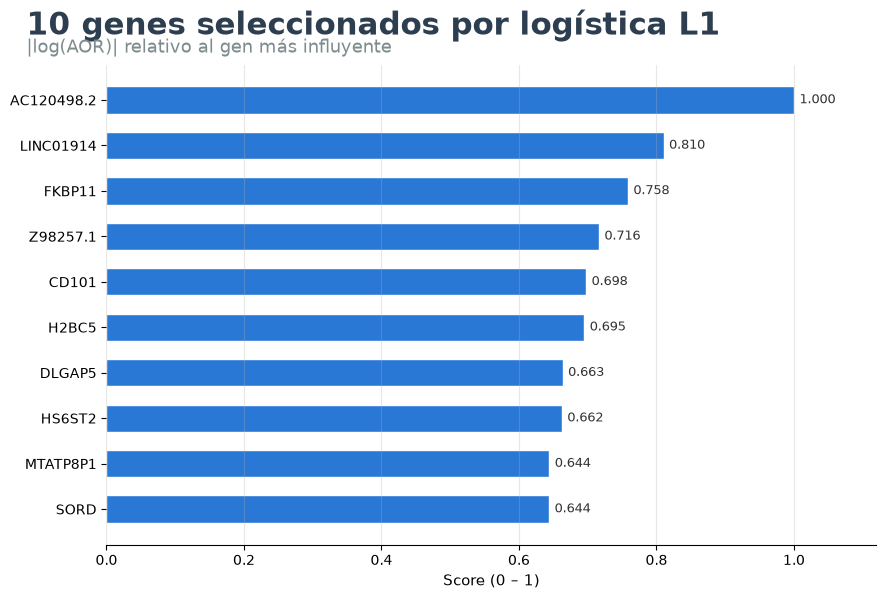

In [24]:
from utils.mutual_inf_plot import graficar_score_relevancia

importancia = (top_l1 / top_l1.max()).to_frame("importancia")
importancia.index = anotacion.loc[top_l1.index, "gene_name"]

graficar_score_relevancia(
    importancia,
    columna="importancia",
    titulo="10 genes seleccionados por logística L1",
    subtitulo="|log(AOR)| relativo al gen más influyente",
    color="#2a78d6",
    figsize=(10, 6),
);

---
## Curaduría: ontología de los 10 genes

A diferencia de KIRP, aquí la firma **no** apunta en una sola dirección: **siete
genes tienen AOR > 1** (suben con el tumor) y **tres AOR < 1** (marcan el tejido
normal). Tampoco es una firma de genes bien caracterizados: cuatro de los diez
son ARN no codificantes o un pseudogén, lo que obliga a ser prudente en la
lectura biológica.

Ejemplo de lectura: *AC120498.2* tiene AOR 1,282, es decir que cada desviación
estándar adicional de expresión multiplica por 1,28 las odds de que la muestra
sea tumor —las aumenta ~28 %— ajustando por los otros nueve genes.

| Gen | AOR | Dirección | Ontología / función | Relación con el LUAD |
| --- | --- | --- | --- | --- |
| **AC120498.2** | 1.282 | tumor | lncRNA sin función establecida | Sin anotación funcional; es la señal más fuerte de la firma, lo que exige cautela |
| **LINC01914** | 0.818 | normal | lncRNA, poco caracterizado | Reportado a la baja en tumores de pulmón, pero sin mecanismo establecido |
| **FKBP11** | 1.207 | tumor | Inmunofilina del retículo endoplásmico, isomerasa de prolil-peptidil | Ligada a diferenciación secretora y estrés del RE, procesos activos en el epitelio tumoral |
| **Z98257.1** | 1.195 | tumor | lncRNA sin función establecida | Sin anotación funcional |
| **CD101** | 0.841 | normal | Receptor inmunorregulador (IGSF2) de linfocitos T y células mieloides | Refleja las poblaciones inmunes residentes del pulmón normal, que el tumor desplaza |
| **H2BC5** | 1.188 | tumor | Histona H2B de replicación dependiente | Los genes de histonas suben en células que replican ADN: marcador de proliferación |
| **DLGAP5** | 1.179 | tumor | Proteína del huso mitótico (HURP), regulada por el ciclo celular | Marcador de proliferación clásico, presente en múltiples firmas tumorales |
| **HS6ST2** | 1.179 | tumor | 6-O-sulfotransferasa de heparán sulfato | Modifica el heparán sulfato y con ello la señalización de factores de crecimiento (FGF, VEGF) |
| **MTATP8P1** | 0.852 | normal | Pseudogén de la ATP sintasa mitocondrial (*MT-ATP8*) | Su cuantificación es ambigua por multimapeo con el gen mitocondrial real: trátese como señal técnica, no biológica |
| **SORD** | 1.173 | tumor | Sorbitol deshidrogenasa, vía de los polioles | Reprogramación metabólica del tumor |

**La lectura de conjunto** es un eje de proliferación (*DLGAP5*, *H2BC5*) y
remodelación de la señalización y el metabolismo (*HS6ST2*, *FKBP11*, *SORD*)
que sube con el tumor, frente a marcadores de pulmón normal —en particular el
componente inmune residente (*CD101*)— que bajan.

**Cuatro salvedades.** Las AOR vienen de un ajuste penalizado: están encogidas
hacia 1, son conservadoras, y esta estimación no produce valores p ni intervalos
de confianza. El contraste es tumor contra tejido normal adyacente, así que
habla del desarrollo del tumor y de su diagnóstico, no de agresividad ni
supervivencia. Por la correlación entre genes, esta lista es *una* firma válida
entre varias casi equivalentes. Y el desbalance es fuerte (542 vs. 59), así que
las 59 muestras normales cargan con todo el peso del contraste.